# clone detection

In [1]:
import gzip, time
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import seaborn as sns
from Bio.Seq import Seq
from collections import Counter
import os
import cassiopeia as cas
from cassiopeia.mixins import logger
from typing import Dict, List, Tuple
from pathlib import Path
import ngs_tools as ngs
import matplotlib.colors as mcolors
import random
import Levenshtein
from tqdm.notebook import tqdm


from cassiopeia.preprocess import (
    alignment_utilities,
    constants,
    map_utils,
    doublet_utils,
    lineage_utils,
    UMI_utils,
    utilities,
)

In [2]:
##########################################################################################################
## error correct whitelist, at largest 3 distances
def error_correct_intBC(
    umi_table: pd.DataFrame,
    dist_thresh:int=3,
) -> pd.DataFrame:
    
    whitelist="/syn2/zhaolian/3.JiLab/results/1.BarcodeSeq/Barcode_list_filtered.txt"
    if isinstance(whitelist, list):
        whitelist_set = set(whitelist)
    else:
        with open(whitelist, "r") as f:
            whitelist_set = set(
                line.strip() for line in f if not line.isspace()
            )
    whitelist = list(whitelist_set)
    
    unique_intbcs = list(umi_table["intBC"].unique())
    corrections = {intbc: intbc for intbc in whitelist_set}
    print(f"{len(unique_intbcs)} intBCs detected.")
    intbc_dist_thresh=dist_thresh
    for intbc in tqdm(unique_intbcs, desc="Correcting intBCs to whitelist"):
        min_distance = np.inf
        min_wls = []
        if intbc not in whitelist_set:
            for wl_intbc in whitelist:
                distance = Levenshtein.distance(intbc, wl_intbc)
                if distance < min_distance:
                    min_distance = distance
                    min_wls = [wl_intbc]
                elif distance == min_distance:
                    min_wls.append(wl_intbc)
    
        # Correct only if there is one matching whitelist. Discard if there
        # are multiple possible corrections.
        if len(min_wls) == 1 and min_distance <= intbc_dist_thresh:
            corrections[intbc] = min_wls[0]
        else:
            corrections[intbc] = intbc
    
    umi_table["intBC"] = umi_table["intBC"].map(corrections)
    umi_table['inwhitelist']="No"
    umi_table.loc[umi_table['intBC'].isin(whitelist_set), 'inwhitelist'] = 'Yes'
    print(Counter(umi_table['inwhitelist']))
    unique_intbcs = list(umi_table["intBC"].unique())
    print(f"{len(unique_intbcs)} intBCs after correction.")
    return umi_table
    # MCorrected=pd.concat([MCorrected,umi_table],ignore_index=True)
    ##########################################################################################################


# 1. C4007



Calculating C4007_LLT-1...
1837 intBCs detected.


Correcting intBCs to whitelist:   0%|          | 0/1837 [00:00<?, ?it/s]

Counter({'Yes': 91065, 'No': 1154})
1046 intBCs after correction.


Calculating C4007_LLT-2...
1021 intBCs detected.


Correcting intBCs to whitelist:   0%|          | 0/1021 [00:00<?, ?it/s]

Counter({'Yes': 40770, 'No': 400})
667 intBCs after correction.


Calculating C4007_Chest...
1484 intBCs detected.


Correcting intBCs to whitelist:   0%|          | 0/1484 [00:00<?, ?it/s]

Counter({'Yes': 49506, 'No': 500})
991 intBCs after correction.


Calculating C4007_Abdo...
586 intBCs detected.


Correcting intBCs to whitelist:   0%|          | 0/586 [00:00<?, ?it/s]

Counter({'Yes': 34981, 'No': 256})
262 intBCs after correction.
sample
IntT      1495477
LLT-1    42767465
LLT-2     1663216
LvT-1       63459
LvT-2     3502233
OvaT      3978410
RLT        480042
ThyT      2623401
Name: readCount, dtype: int64
sample
IntT      1503
LLT-1    14451
LLT-2     6909
LvT-1       98
LvT-2     3080
OvaT      4621
RLT       2026
ThyT     10036
Name: cellBC, dtype: int64
                  cellBC sample                        intBC  num
1  IntT_AAAGGATAGACATAGT   IntT  CATGAGTCTGTCCACCCCTTCCTCTGT    2
2  IntT_AAAGGATAGCAACCAG   IntT  CATCGCGCTTCTAACAGTTTCTTGTGT    2
3  IntT_AAAGGATAGCAACCAG   IntT  CATGGTCCTTGCAACACTCTCCTACGT    3
sample
IntT      1495477
LLT-1    42767465
LLT-2     1663216
LvT-1       63459
LvT-2     3502233
OvaT      3978410
RLT        480042
ThyT      2623401
Name: readCount, dtype: int64
sample
IntT      1503
LLT-1    14451
LLT-2     6909
LvT-1       98
LvT-2     3080
OvaT      4621
RLT       2026
ThyT     10036
Name: cellBC, dtype: int64


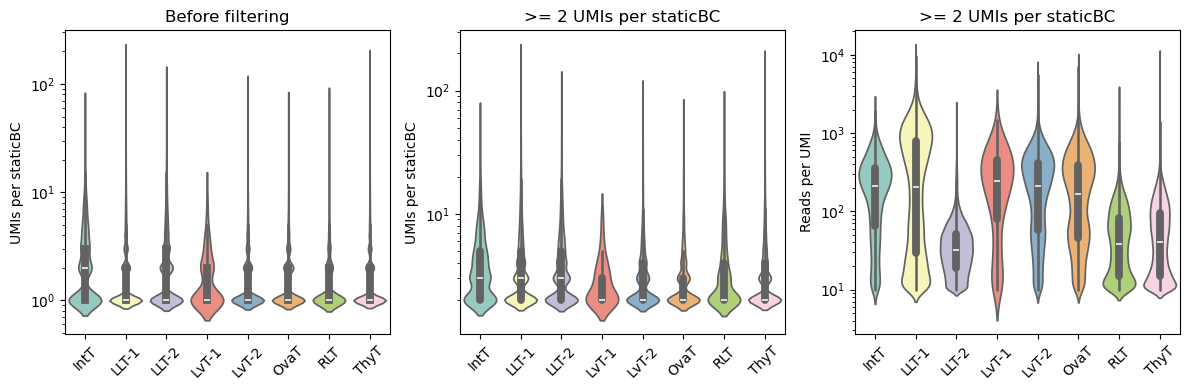

In [3]:
SCDIR = "/syn2/zhaolian/3.JiLab/results/2.scRNAseq/2.scFiltered/"
AMPLICONDIR = "/syn2/zhaolian/3.JiLab/results/1.BarcodeSeq/03.cassiopeia_out/"
OUTDIR = "/syn2/zhaolian/3.JiLab/results/1.BarcodeSeq/04.clone/"
FIGDIR = "/syn2/zhaolian/3.JiLab/results/figures/"
# tagging information
my_mouse = "C4007"
samplesAmplicon = ["LLT-1","LLT-2","Chest","Abdo"]#"Chest",
samplesSC = [["LLT-1"],["LLT-2"],["RLT","ThyT"],["LvT-1","LvT-2","OvaT","IntT"]]#
INDIR = os.path.join(AMPLICONDIR, my_mouse, "/")


# 1. prepare meta info
# prepare cellBC from scRNAseq, one file for each mouse
# bc_all = pd.read_table(os.path.join(SCDIR, f"{my_mouse}_scdataDF_metadata.txt"), header=0)
# bc_all["cellBC"] = bc_all.index.str.split("_").str[1]
# bc_all["cellBC"] = bc_all["cellBC"].str.split("-").str[0]
# bc_all["mouse"] = bc_all["sampleID"].str.split("_").str[0]
# bc_all["sampleID"] = bc_all["sampleID"].str.split("_").str[1]
bc_all = pd.read_table("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byType/scdata_metadata_node.txt", header=0)
bc_all=bc_all[bc_all["mouse"]==my_mouse]

umi_table = pd.DataFrame()
for my_sample in range(len(samplesAmplicon)):
    print(f"\n\nCalculating {my_mouse}_{samplesAmplicon[my_sample]}...")
    
    # 1.
    x = pd.read_csv(os.path.join(AMPLICONDIR, f"{my_mouse}/{samplesAmplicon[my_sample]}_umi_table_filtered.csv"),sep='\t', header=0)
    bc = bc_all[bc_all['sampleID'].isin(samplesSC[my_sample])]
    # dt = x[x['cellBC'].isin(bc['cellBC'])]
    dt=pd.merge(x, bc, on='cellBC', how='inner')
    dt['cellBC']=dt['sampleID']+"_"+dt['cellBC']

    # print(len(dt.cellBC.unique()),len(dt.UMI.unique()),dt.readCount.sum())
    
    # 2. get staticBC
    dt = dt.rename(columns={'sampleID': 'sample'})
    dt['primer'] = dt['seq'].str[:21]
    dt['intBC'] = dt['seq'].str[21:49]
    dt['isceI'] = dt['seq'].str[48:84]

    # dt=error_correct_intBC(dt,dist_thresh=3)
    ##---------------------------------------------------------------------------
    ## 3. read2: primer (dist<=2); isceI (dist<=3); >= 2 UMIs per staticBC 
    df_filt=dt.copy().reset_index()
    # df_filt=df_filt[['']]
    df_filt['primer']=df_filt.seq.str[:21]
    df_filt['intBC']=df_filt.seq.str[21:48]
    df_filt=error_correct_intBC(df_filt,dist_thresh=3)
    df_filt['isceI']=df_filt.seq.str[48:83]
    df_filt['distance_primer']=[ngs.sequence.levenshtein_distance(df_filt.loc[i,'primer'], "TTGAATCGTACCCTGTATAGG") for i in range(len(df_filt))]
    df_filt['distance_isceI']=[ngs.sequence.levenshtein_distance(df_filt.loc[i,'isceI'], "GGATCCGTGCGTATCTATAGGGATAACAGGGTAAT") for i in range(len(df_filt))]
    df_filt=df_filt[df_filt['distance_primer']<=2]
    df_filt=df_filt[df_filt['distance_isceI']<=2]
    umi_table = pd.concat([umi_table, df_filt], ignore_index=True)
    # print(len(df_filt.cellBC.unique()),len(df_filt.UMI.unique()),df_filt.readCount.sum())
umi_table=umi_table.sort_values('sample')
umi_table.index = range(0,umi_table.shape[0])
print(umi_table.groupby('sample').readCount.sum())
print(umi_table.groupby('sample').cellBC.nunique())
## remove intBC with low UMIs
umi_table['num'] = 1
umi_count = umi_table.groupby(by=['cellBC','sample','intBC'])['num'].sum().reset_index()
umi_count = umi_count[umi_count['num'] > 0]   ## !!! whether using this threshold
print(umi_count.loc[1:3,])

umi_table_tmp = pd.merge(umi_table,umi_count,how='inner',on=['sample','cellBC','intBC'])
umi_table_tmp.to_csv(OUTDIR+my_mouse+"_umi_table_filtered.txt",sep='\t')
print(umi_table_tmp.groupby('sample').readCount.sum())
print(umi_table_tmp.groupby('sample').cellBC.nunique())

##
fig, axes = plt.subplots(1, 3, figsize=(12, 4))#, sharey=True
## plot1
sns.violinplot(ax=axes[0],x='sample',y = "num",hue="sample",data = umi_count,palette="Set3", log_scale=True)
sns.set_style(style='white')
axes[0].set_title("Before filtering")
axes[0].set_xlabel("")
axes[0].set_ylabel("UMIs per staticBC")
axes[0].tick_params('x',labelrotation=45)
## plot2
temp2=umi_count[umi_count['num']>1]
sns.violinplot(ax=axes[1],x='sample',y = "num",hue="sample",data = temp2,palette="Set3", log_scale=True)
axes[1].set_title(">= 2 UMIs per staticBC")
axes[1].set_xlabel("")
axes[1].set_ylabel("UMIs per staticBC")
axes[1].tick_params('x',labelrotation=45)
## plot3
sns.violinplot(ax=axes[2],x='sample',y = "readCount",hue="sample",data = umi_table_tmp,palette="Set3", log_scale=True)
axes[2].set_title(">= 2 UMIs per staticBC")
axes[2].set_xlabel("")
axes[2].set_ylabel("Reads per UMI")
axes[2].tick_params('x',labelrotation=45)
fig.tight_layout()

## call clone

In [ ]:
umi_table_tmp = pd.merge(umi_table,umi_count,how='inner',on=['sample','cellBC','intBC'])
piv = pd.pivot_table(
        umi_table_tmp, index="cellBC", columns="intBC", values="UMI", aggfunc="count"
    )
piv.shape
piv = piv.fillna(0)
piv = piv.div(piv.sum(axis=1), axis=0) #  normalizing the rows,  the sum of each row equals 1
pivbin = piv.copy()
pivbin[pivbin > 0] = 1
intBC_sums = pivbin.sum(0) # sum each columns
ordered_intBCs = intBC_sums.sort_values(ascending=False).index.tolist() # order staticBC descending

piv = piv.loc[pivbin.index[pivbin.sum(1) > 0],ordered_intBCs]  ## subset at least 1 staticBC, order staticBC
# sorted(pivbin.sum(0))[::-1] # 倒序

min_clust_size = 4.5 # min clone size > 5
min_intbc_thresh = 0.6  # the minimum proportion of cells in a lineage group that need to have an intBC; 
                        # or minimum proportion of cells that share an intBC with the most frequent intBC
                        # in forming putative lineage groups
kinship_thresh = 0.1   # The threshold specifying the minimum proportion of intBCs shared between a cell 
                        # and the intBC set of a lineage group needed to assign that cell to that lineage
                        # group in putative assignment
## 1. assigning with min_clust_size
logger.info("Assigning initial lineage groups...")
logger.info(f"Clustering with minimum cluster size {min_clust_size}...")
piv_assigned = lineage_utils.assign_lineage_groups(
    piv,
    min_clust_size,
    min_intbc_thresh=min_intbc_thresh,
    kinship_thresh=kinship_thresh,
)
tmp = piv_assigned.copy()
piv_assigned
# print(piv_assigned['lineageGrp'].value_counts())
## 2. refining by removing low min_intbc_thresh
logger.info("Refining lineage groups...")
logger.info("Redefining lineage groups by removing low proportion intBCs...")
master_LGs, master_intBCs = lineage_utils.filter_intbcs_lg_sets(
    piv_assigned, min_intbc_thresh=min_intbc_thresh
)
# print(piv_assigned['lineageGrp'].value_counts())
## 3. reassigning by kinship
logger.info("Reassigning cells to refined lineage groups by kinship...")
kinship_scores = lineage_utils.score_lineage_kinships(
    piv_assigned, master_LGs, master_intBCs
)
kinship_scores = kinship_scores[kinship_scores['maxOverlap'] > 0.1] # doublet remove
piv_assigned = piv_assigned.loc[kinship_scores.index,:]
piv_assigned['lineageGrp'] = kinship_scores['lineageGrp']
piv_assigned['lineageGrp'] = pd.Categorical(piv_assigned['lineageGrp'], categories=piv_assigned['lineageGrp'].value_counts().index, ordered=True)
piv_assigned = piv_assigned.sort_values('lineageGrp')
# print(piv_assigned['lineageGrp'].value_counts())
## 4. refiltering by min_intbc_thresh
logger.info("Filtering out low proportion intBCs in finalized lineage groups...")
master_LGs, master_intBCs = lineage_utils.filter_intbcs_lg_sets(
    piv_assigned, min_intbc_thresh=min_intbc_thresh
)
# print(piv_assigned['lineageGrp'].value_counts())

##--------------------------------------------------------
## finalize lineage group table
##--------------------------------------------------------
LGs = []
for LG in  piv_assigned['lineageGrp']:
    if LG in LGs:
        pass
    else:
        LGs.append(LG)
intBCs_all = []
master_intBCs_filtered = {} 
for LG in LGs:
    intBCs = master_intBCs[(int(LG),)]
    intBCs = list(set(intBCs).difference(set(intBCs_all)))
    master_intBCs_filtered[(int(LG),)] = intBCs
    intBCs_all = intBCs_all + intBCs
    
intBCs_final = sum(list(master_intBCs_filtered.values()),[]) 
# print(master_intBCs_filtered)
print(len(intBCs_final))

##################################################################
print('NUmber of clones: '+str(len(piv_assigned['lineageGrp'].value_counts().index)))
piv_assigned['cellBC']=[i+'_'+str(piv_assigned.loc[i,'lineageGrp']) for i in piv_assigned.index]
piv_assigned.set_index('cellBC',inplace=True)

piv_assigned_sub = piv_assigned.iloc[:,0:piv_assigned.shape[1]-1]
piv_assigned_sub[piv_assigned_sub > 0] = 1
piv_assigned_sub = piv_assigned_sub.loc[:,intBCs_final]
piv_assigned_sub.to_csv(OUTDIR+my_mouse+"_assigned_clones.txt",sep='\t')
ax = sns.clustermap(piv_assigned_sub, cmap='binary',figsize=(4, 5),row_cluster=False,col_cluster=False,yticklabels=False,xticklabels=False)#yticklabels=False,xticklabels=False,,cbar=False,figsize=(7, 7)
ax.cax.set_visible(False)

# out of clone cells are mask 0
for LG in master_intBCs_filtered:
    intBCs = master_intBCs_filtered[LG]
    # print(LG)
    piv_assigned.loc[piv_assigned.lineageGrp==LG[0],
                 [intBC not in intBCs for intBC in piv_assigned.columns[0:-1]] + [False]] = 0
    
    piv_assigned.loc[[lin != LG[0] for lin in piv_assigned.lineageGrp],intBCs] = 0
piv_assigned_sub = piv_assigned.iloc[:,0:piv_assigned.shape[1]-1]
piv_assigned_sub[piv_assigned_sub > 0] = 1
piv_assigned_sub = piv_assigned_sub[piv_assigned_sub.sum(1)>0]
piv_assigned_sub = piv_assigned_sub.loc[:,intBCs_final]
##############################
temp=piv_assigned_sub
temp['cellBC']=temp.index
temp['lineageGrp']=[i.split('_')[2] for i in temp.index]
clone_counts=temp['lineageGrp'].value_counts().sort_values(ascending=False).reset_index(name='counts')
clone_counts['lg']=clone_counts.index+1
temp_lg=pd.merge(temp,clone_counts,how='inner',on=['lineageGrp'])
temp_lg['sample']=temp_lg['cellBC'].str.split('_').str[0]
temp_lg['cell']=temp_lg['cellBC'].str.split('_').str[1]
temp_lg['cellBC']=temp_lg['sample']+'_'+temp_lg['cell']+'_'+temp_lg['lg'].astype(str)
temp_lg.set_index('cellBC',inplace=True)
piv_assigned_sub = temp_lg.iloc[:,0:temp_lg.shape[1]-5]
##############################
piv_assigned_sub.to_csv(OUTDIR+my_mouse+"_assigned_clones_clean.txt",sep='\t')
print(piv_assigned_sub.shape)
# ax = sns.clustermap(piv_assigned_sub, cmap='binary',figsize=(4, 5),row_cluster=False,col_cluster=False,yticklabels=False,xticklabels=False)#yticklabels=False,xticklabels=False,,cbar=False,figsize=(7, 7)
# ax.cax.set_visible(False)
# sns.histplot(piv_assigned_sub.apply(sum,axis=1).sort_values())
# plt.hist(piv_assigned_sub.apply(sum,axis=1).sort_values())
# plt.xlabel('static barcode counts per cell')
# plt.ylabel('Frequency')
##------------------------------------------------------------
temp=piv_assigned_sub
temp['sample']=[i.split('_')[0] for i in piv_assigned_sub.index]
temp['clone']=[i.split('_')[2] for i in piv_assigned_sub.index]
temp
samples=temp.pop("sample")
clones=temp.pop("clone")

lut = dict(zip(samples.unique(), sns.color_palette("Set1",len(samples.unique()))))
row_colors = samples.map(lut)
g=sns.clustermap(piv_assigned_sub, cmap='binary',figsize=(4, 5),
               row_cluster=False,col_cluster=False,yticklabels=False,xticklabels=False,
                 row_colors=row_colors)

for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc="center", ncol=4)

g.cax.set_position([.08, .2, .03, .45])
g.savefig(FIGDIR+my_mouse+"_clones_heatmap.png", format='png')

[2024-11-03 23:32:27,220]    INFO [main] Assigning initial lineage groups...
[2024-11-03 23:32:27,221]    INFO [main] Clustering with minimum cluster size 4.5...
[2024-11-03 23:33:22,659]    INFO [main] Refining lineage groups...
[2024-11-03 23:33:22,660]    INFO [main] Redefining lineage groups by removing low proportion intBCs...
[2024-11-03 23:33:29,878]    INFO [main] Reassigning cells to refined lineage groups by kinship...
[2024-11-03 23:33:35,218]    INFO [main] Filtering out low proportion intBCs in finalized lineage groups...


265
NUmber of clones: 257


/tmp/ipykernel_165944/1034161146.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  piv_assigned['cellBC']=[i+'_'+str(piv_assigned.loc[i,'lineageGrp']) for i in piv_assigned.index]


(41773, 265)


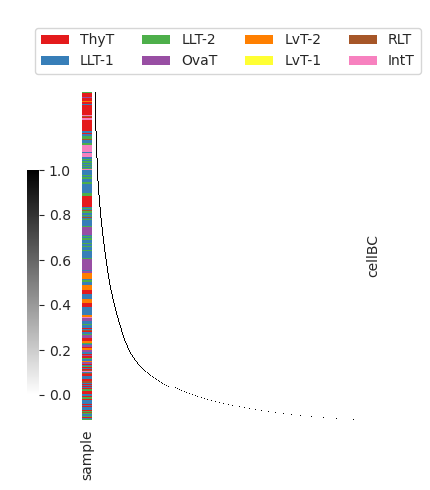

In [9]:
g=sns.clustermap(piv_assigned_sub, cmap='binary',figsize=(4, 5),
               row_cluster=False,col_cluster=False,yticklabels=False,xticklabels=False,
                 row_colors=row_colors)

for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc="center", ncol=4)

g.cax.set_position([.08, .2, .03, .45])
g.savefig(FIGDIR+my_mouse+"_clones_heatmap.png", format='png')

###### plt.hist(piv_assigned_sub.apply(sum,axis=1).sort_values())
plt.xlabel('static barcode counts per cell')
plt.ylabel('Frequency')

piv_assigned_sub.apply(sum,axis=1).sort_values().value_counts()